# Dataset Exploration: Human Movement

This notebook explores the experimental movement dataset collected for the Adaptive Embodied AI project.

The dataset contains webcam-based upper-body movement recordings from multiple participants and sessions. Pose landmarks were converted into a compact set of 2D and 3D movement features.

The purpose of this analysis is to:

1. understand the structure of the collected data;
2. inspect the distribution of movement classes;
3. examine movement-specific feature variation;
4. investigate participant and session differences; and
5. identify considerations for the modelling stage.

The analysis is exploratory. It does not train models or evaluate
generalisation.

## Experimental Design

The dataset follows a participant/session/trial hierarchy:

- **Participant** — individual performing the movements
- **Session** — separate recording session
- **Trial** — one execution of a movement
- **Movement class** — instructed movement

The current dataset contains:

- 2 participants
- 2 sessions per participant
- 25 trials per session
- 5 movement classes
- 5 repetitions of each movement per session

Movement classes:

- `neutral`
- `raise_arms`
- `lean_left`
- `lean_right`
- `lean_forward`

Each trial contains a short temporal sequence of pose-derived movement
features.

In [1]:
# Imports and load dataset

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("../data/movement")

files = sorted(DATA_DIR.glob("P*_session_*.csv"))

if not files:
    raise FileNotFoundError(
        f"No participant/session CSV files found in {DATA_DIR.resolve()}"
    )

frames = [pd.read_csv(file) for file in files]

df = pd.concat(frames, ignore_index=True)

print(f"Files loaded: {len(files)}")
print(f"Dataset shape: {df.shape}")

Files loaded: 4
Dataset shape: (12049, 14)


Each participant/session recording is stored as a separate CSV file and is combined into one dataframe for analysis. Participant, session, and trial identifiers are retained throughout the notebook.

In [2]:
display(df.head())

,participant_id,session_id,trial_id,movement_label,timestamp,shoulder_width,head_offset_x,head_offset_y,torso_dx,torso_dy,movement_speed,head_offset_z,torso_dz,movement_speed_3d
0,P01,session_01,1,neutral,0.000286,0.512240,-0.003828,-0.809468,0.000000,0.000000,0.000000,-1.819797,0.000000,0.000000
1,P01,session_01,1,neutral,0.089765,0.522485,0.001988,-0.821021,0.001142,0.041825,0.467600,-1.964989,-0.080764,1.016539
2,P01,session_01,1,neutral,0.120218,0.526950,-0.002607,-0.825294,0.004594,0.006284,0.255614,-1.953916,-0.004368,0.293103
3,P01,session_01,1,neutral,0.161072,0.528400,-0.000946,-0.826692,0.001198,0.004504,0.114079,-1.970659,-0.041060,1.011501
4,P01,session_01,1,neutral,0.199235,0.528685,-0.000832,-0.819518,-0.000120,0.001390,0.036564,-2.000928,-0.021275,0.558671


In [3]:
# Dataset overview

feature_columns = [
    "shoulder_width",
    "head_offset_x",
    "head_offset_y",
    "torso_dx",
    "torso_dy",
    "movement_speed",
    "head_offset_z",
    "torso_dz",
    "movement_speed_3d",
]

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Participants: {df['participant_id'].nunique()}")
print(f"Sessions: {df['session_id'].nunique()}")
print(f"Trials: {df['trial_id'].nunique()}")
print(f"Movement classes: {df['movement_label'].nunique()}")

display(df[["participant_id", "session_id", "trial_id", "movement_label"]]
        .head())

Rows: 12,049
Columns: 14
Participants: 2
Sessions: 2
Trials: 25
Movement classes: 5


,participant_id,session_id,trial_id,movement_label
0,P01,session_01,1,neutral
1,P01,session_01,1,neutral
2,P01,session_01,1,neutral
3,P01,session_01,1,neutral
4,P01,session_01,1,neutral


The dataset contains 12,049 frame-level observations across 100 trials. The modelling unit will later be the trial, with each trial represented as a short temporal sequence rather than as independent frames.

In [4]:
# Trial structure

trial_summary = (
    df.groupby(
        ["participant_id", "session_id"],
        as_index=False
    )
    .agg(
        trials=("trial_id", "nunique"),
        movements=("movement_label", "nunique"),
        observations=("trial_id", "size"),
    )
)

display(trial_summary)

,participant_id,session_id,trials,movements,observations
0,P01,session_01,25,5,3013
1,P01,session_02,25,5,3011
2,P02,session_01,25,5,3012
3,P02,session_02,25,5,3013


In [5]:
movement_counts = (
    df[
        ["participant_id", "session_id", "trial_id", "movement_label"]
    ]
    .drop_duplicates()["movement_label"]
    .value_counts()
    .sort_index()
)

display(movement_counts)

movement_label
lean_forward    20
lean_left       20
lean_right      20
neutral         20
raise_arms      20
Name: count, dtype: int64

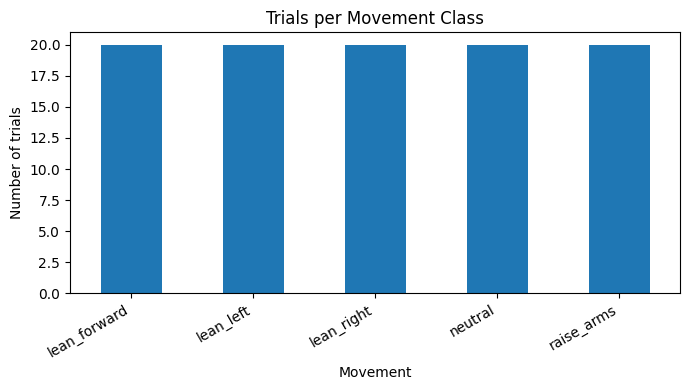

In [6]:
plt.figure(figsize=(7, 4))

movement_counts.plot(kind="bar")

plt.title("Trials per Movement Class")
plt.xlabel("Movement")
plt.ylabel("Number of trials")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [7]:
# emporal structure

trial_stats = (
    df.groupby(
        ["participant_id", "session_id", "trial_id", "movement_label"]
    )
    .agg(
        observations=("timestamp", "size"),
        duration=("timestamp", lambda x: x.max() - x.min()),
    )
    .reset_index()
)

print(
    f"Observations per trial: "
    f"{trial_stats['observations'].min()}–"
    f"{trial_stats['observations'].max()}"
)

print(
    f"Trial duration: "
    f"{trial_stats['duration'].min():.3f}–"
    f"{trial_stats['duration'].max():.3f} s"
)

Observations per trial: 117–121
Trial duration: 3.952–4.000 s


Trials contain approximately 117–121 observations over approximately four seconds. Small differences in sequence length are expected from webcam-based acquisition.

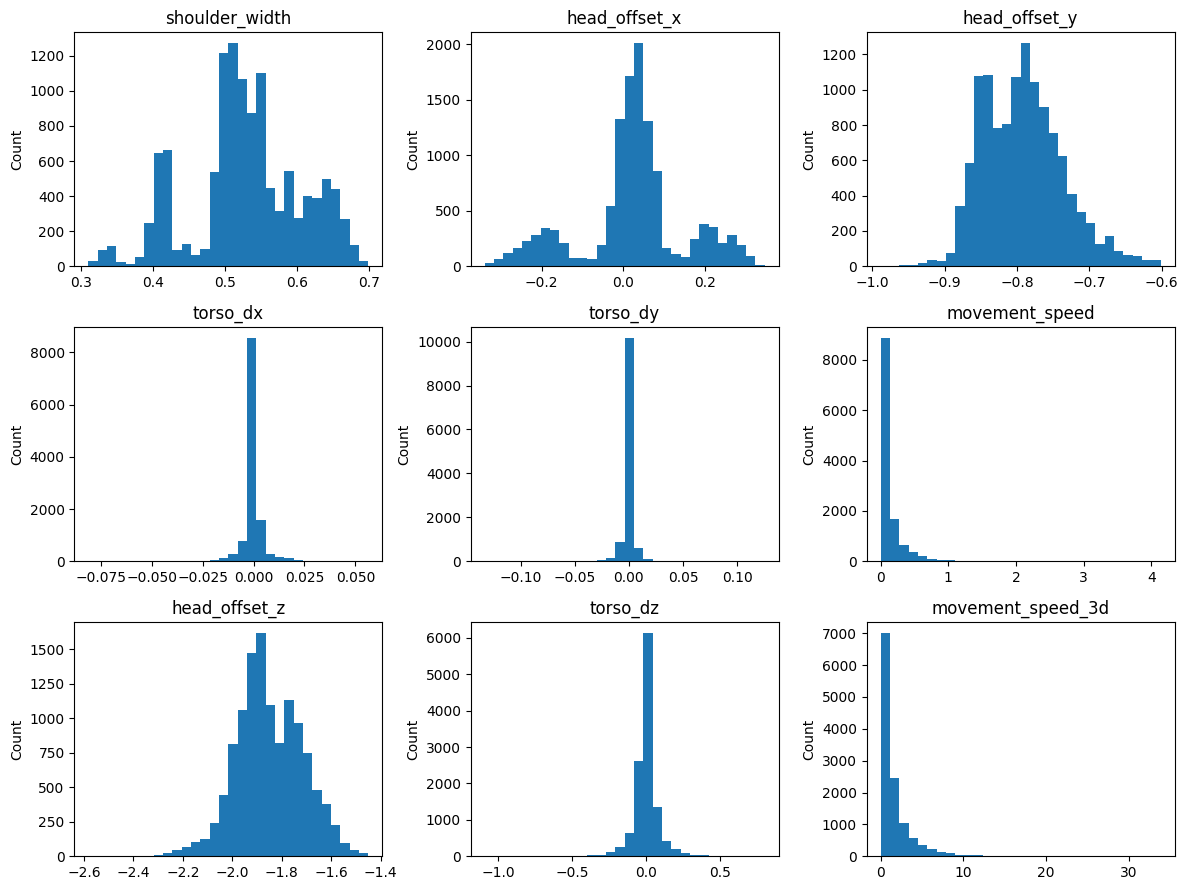

In [8]:
# Feature distributions

fig, axes = plt.subplots(
    3, 3, figsize=(12, 9)
)

for ax, feature in zip(axes.flat, feature_columns):
    ax.hist(df[feature], bins=30)
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [9]:
display(
    df[feature_columns]
    .describe()
    .T[
        ["mean", "std", "min", "25%", "50%", "75%", "max"]
    ]
    .round(4)
)

,mean,std,min,25%,50%,75%,max
shoulder_width,0.5287,0.0767,0.3107,0.4946,0.5262,0.5797,0.6991
head_offset_x,0.0223,0.1277,-0.3399,-0.0141,0.0285,0.0711,0.3464
head_offset_y,-0.7924,0.0553,-0.9886,-0.8371,-0.7941,-0.7577,-0.6015
torso_dx,0.0001,0.0050,-0.0811,-0.0010,-0.0000,0.0009,0.0564
torso_dy,-0.0003,0.0065,-0.1334,-0.0012,-0.0000,0.0010,0.1253
movement_speed,0.1317,0.2100,0.0000,0.0262,0.0627,0.1468,4.1384
head_offset_z,-1.8499,0.1350,-2.5817,-1.9379,-1.8649,-1.7527,-1.4495
torso_dz,0.0002,0.0907,-1.0912,-0.0285,-0.0002,0.0273,0.8017
movement_speed_3d,1.6312,2.2370,0.0000,0.3511,0.8690,1.9766,33.8756


In [10]:
# Movement-specific features

selected_features = [
    "head_offset_x",
    "head_offset_y",
    "head_offset_z",
    "movement_speed_3d",
]

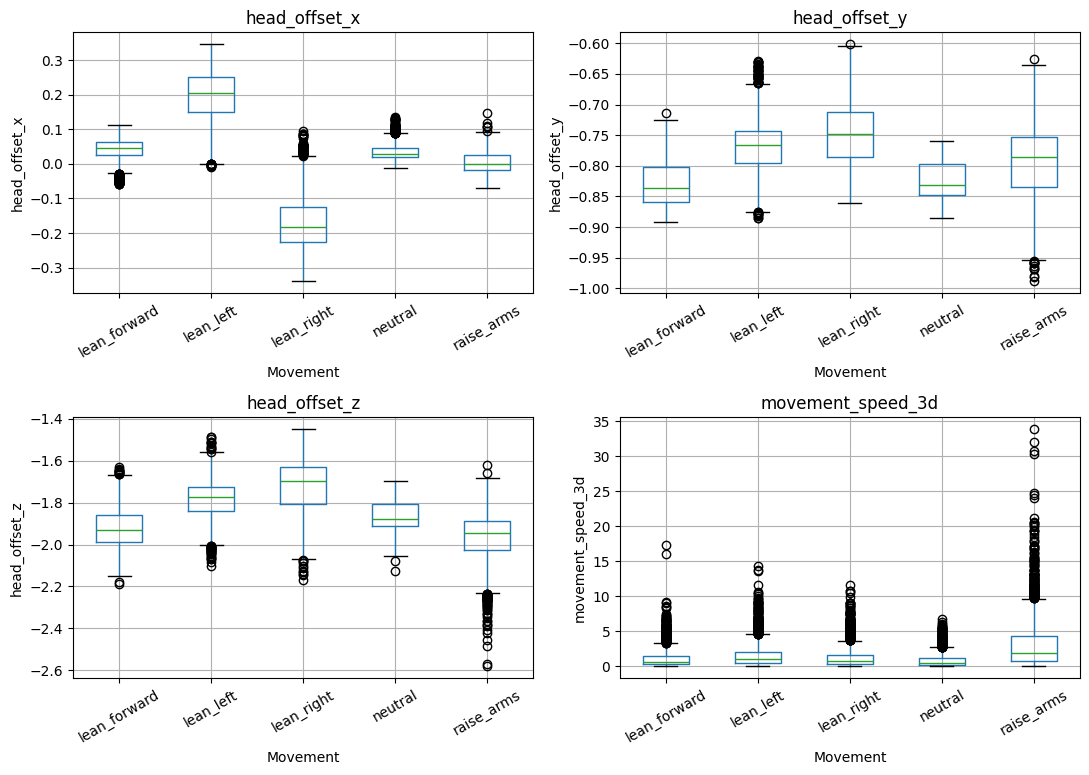

In [11]:
fig, axes = plt.subplots(
    2, 2, figsize=(11, 8)
)

for ax, feature in zip(axes.flat, selected_features):
    df.boxplot(
        column=feature,
        by="movement_label",
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("Movement")
    ax.set_ylabel(feature)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("")
plt.tight_layout()
plt.show()

The distributions show that several features vary across movement classes. In particular, lateral head position and 3D movement speed show visible movement-specific differences.

This indicates that the extracted representation contains information related to the instructed movement. However, these plots are descriptive and do not establish classification performance or generalisation.

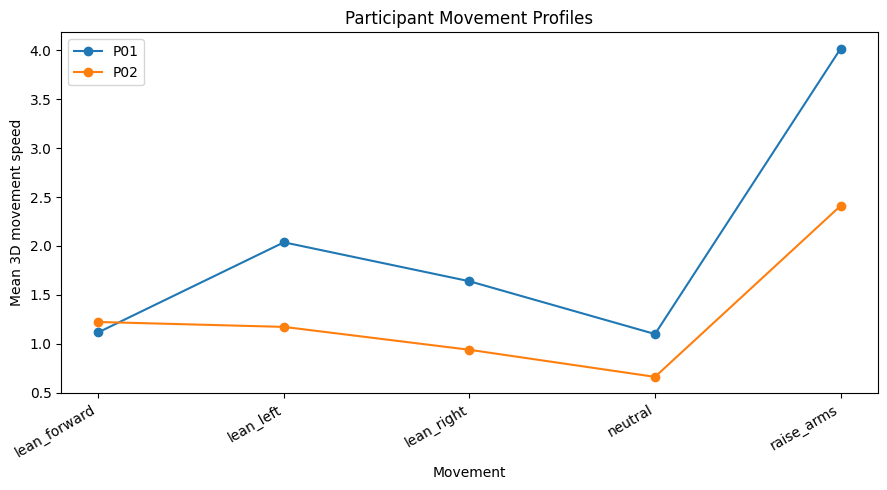

In [12]:
# Participant and session variation

participant_means = (
    df.groupby(
        ["participant_id", "movement_label"]
    )["movement_speed_3d"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

for participant, group in participant_means.groupby("participant_id"):
    plt.plot(
        group["movement_label"],
        group["movement_speed_3d"],
        marker="o",
        label=participant
    )

plt.title("Participant Movement Profiles")
plt.xlabel("Movement")
plt.ylabel("Mean 3D movement speed")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

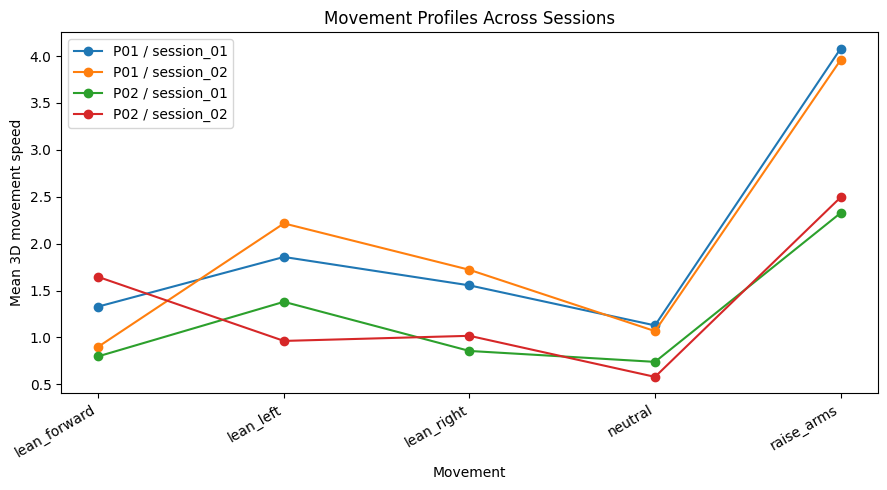

In [13]:
session_means = (
    df.groupby(
        ["participant_id", "session_id", "movement_label"]
    )["movement_speed_3d"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

for (participant, session), group in session_means.groupby(
    ["participant_id", "session_id"]
):
    plt.plot(
        group["movement_label"],
        group["movement_speed_3d"],
        marker="o",
        label=f"{participant} / {session}"
    )

plt.title("Movement Profiles Across Sessions")
plt.xlabel("Movement")
plt.ylabel("Mean 3D movement speed")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

The movement profiles show that the same instructed movement can be expressed with different feature magnitudes across participants. Some variation is also present between sessions of the same participant.

This provides preliminary motivation for investigating personalised modelling. At the same time, the experiment currently contains only two participants, so these observations should not be interpreted as evidence of a general participant effect.

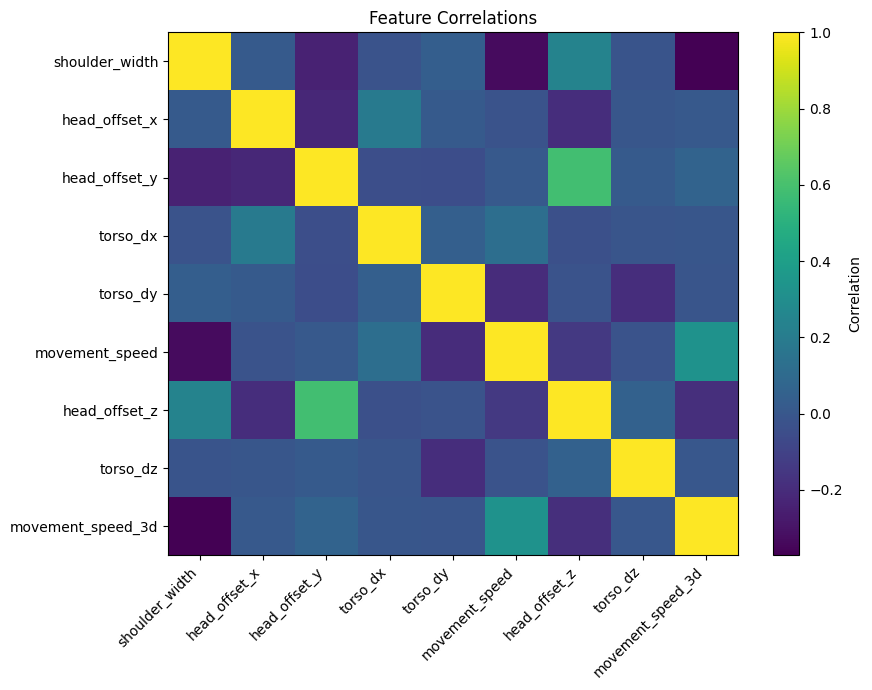

In [14]:
# Feature relationships

correlation = df[feature_columns].corr()

plt.figure(figsize=(9, 7))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.colorbar(label="Correlation")
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()

Most features show relatively weak linear correlations, while some expected relationships are present. For example, `head_offset_y` and `head_offset_z` are moderately correlated, while `movement_speed` and `movement_speed_3d` capture related aspects of movement.

No features are removed at this stage. The complete representation will first be evaluated by the baseline modelling experiment.

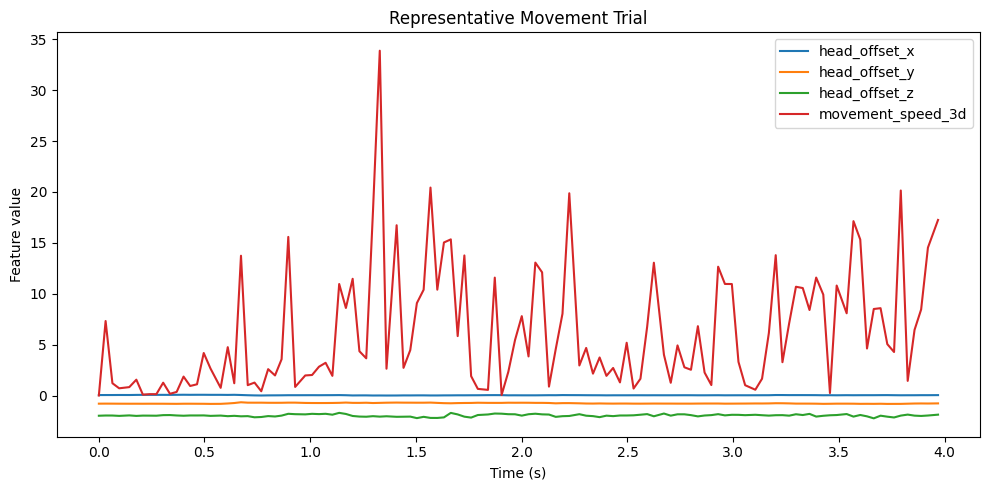

In [15]:
# Temporal example

example = df[
    (df["participant_id"] == "P01")
    & (df["session_id"] == "session_01")
    & (df["trial_id"] == 6)
].copy()

if example.empty:
    raise ValueError("Representative trial was not found.")

temporal_features = [
    "head_offset_x",
    "head_offset_y",
    "head_offset_z",
    "movement_speed_3d",
]

plt.figure(figsize=(10, 5))

for feature in temporal_features:
    plt.plot(
        example["timestamp"],
        example[feature],
        label=feature
    )

plt.title("Representative Movement Trial")
plt.xlabel("Time (s)")
plt.ylabel("Feature value")
plt.legend()
plt.tight_layout()
plt.show()

The feature values change over the duration of a trial rather than remaining constant. This supports representing each trial as a temporal sequence in the modelling stage.

## Preliminary Findings

The exploratory analysis shows four main characteristics of the dataset.

### 1. Balanced experimental structure

The dataset contains 100 trials across two participants, two sessions per participant, and five movement classes. Each movement is represented by 20 trials.

### 2. Movement-specific structure

Several pose-derived features vary systematically across movement classes, particularly head position and 3D movement speed. This suggests that the feature representation contains information relevant to distinguishing the movements.

### 3. Participant and session variation

The same movement is not expressed identically across participants, and some variation is also present between sessions of the same participant. These differences provide preliminary motivation for investigating personalised models.

### 4. Temporal structure

Each trial contains approximately four seconds of sequential observations. Feature values change throughout the trial, supporting a sequence-based modelling approach.

Overall, the dataset appears suitable for the next experimental stage. However, the small number of participants limits the conclusions that can be drawn about generalisable participant-specific effects.

## Next Step: Generic vs Personalised Modelling

The next stage will compare two approaches:

- **Generic model:** trained across participants without participant-specific adaptation.
- **Personalised model:** adapted using data from the target participant.

The modelling experiment will investigate whether participant-specific adaptation improves movement recognition and how performance changes as adaptation data become available.